<a href="https://colab.research.google.com/github/sydas13/ML_Lab_Codes/blob/main/Question3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [129]:
from google.colab import files

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [131]:
uploaded = files.upload()

Saving salary_data.csv to salary_data.csv


In [132]:
data = pd.read_csv("salary_data.csv")  # Change to your filename
print(data.head(), "\n")



   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0 



In [133]:
X = data['YearsExperience'].values
y = data['Salary'].values


In [134]:
X = (X - np.mean(X)) / np.std(X)
y = (y - np.mean(y)) / np.std(y)

In [135]:
def predict(X, theta0, theta1):
    """Hypothesis function h(x) = theta0 + theta1 * x"""
    return theta0 + theta1 * X

In [136]:
def compute_cost(X, y, theta0, theta1):
    """Mean Squared Error cost function"""
    m = len(y)
    predictions = predict(X, theta0, theta1)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost


In [137]:
def gradient_descent(X, y, alpha, epochs):
    """Performs Gradient Descent"""
    theta0, theta1 = 0, 0  # initial parameters
    m = len(y)
    cost_history = []

    plt.figure(figsize=(10, 8))

    for epoch in range(1, epochs + 1):
        y_pred = predict(X, theta0, theta1)
        d_theta0 = (1 / m) * np.sum(y_pred - y)
        d_theta1 = (1 / m) * np.sum((y_pred - y) * X)

        theta0 -= alpha * d_theta0
        theta1 -= alpha * d_theta1

        cost = compute_cost(X, y, theta0, theta1)
        cost_history.append(cost)

        # Plot the hypothesis line after each epoch
        plt.subplot(3, int(np.ceil(epochs / 3)), epoch)
        plt.scatter(X, y, color='blue', label='Data Points')
        plt.plot(X, predict(X, theta0, theta1), color='red')
        plt.title(f'Epoch {epoch}')
        plt.tight_layout()

    plt.show()
    return theta0, theta1, cost_history

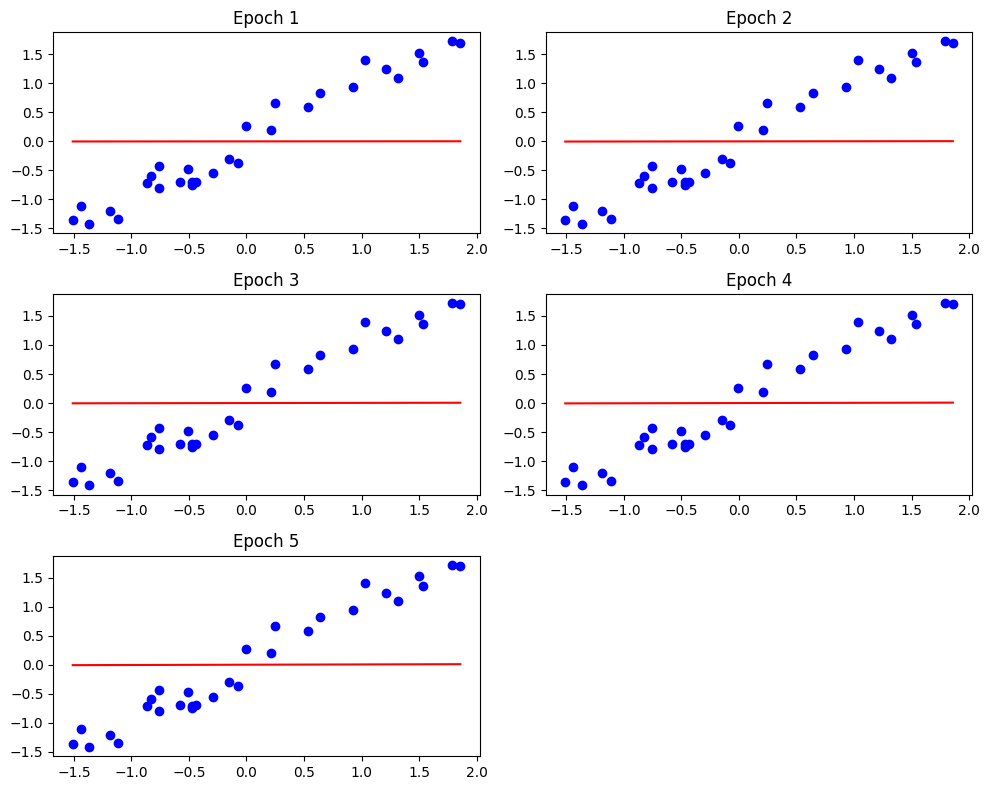

Alpha = 0.001, Final Cost = 0.495237


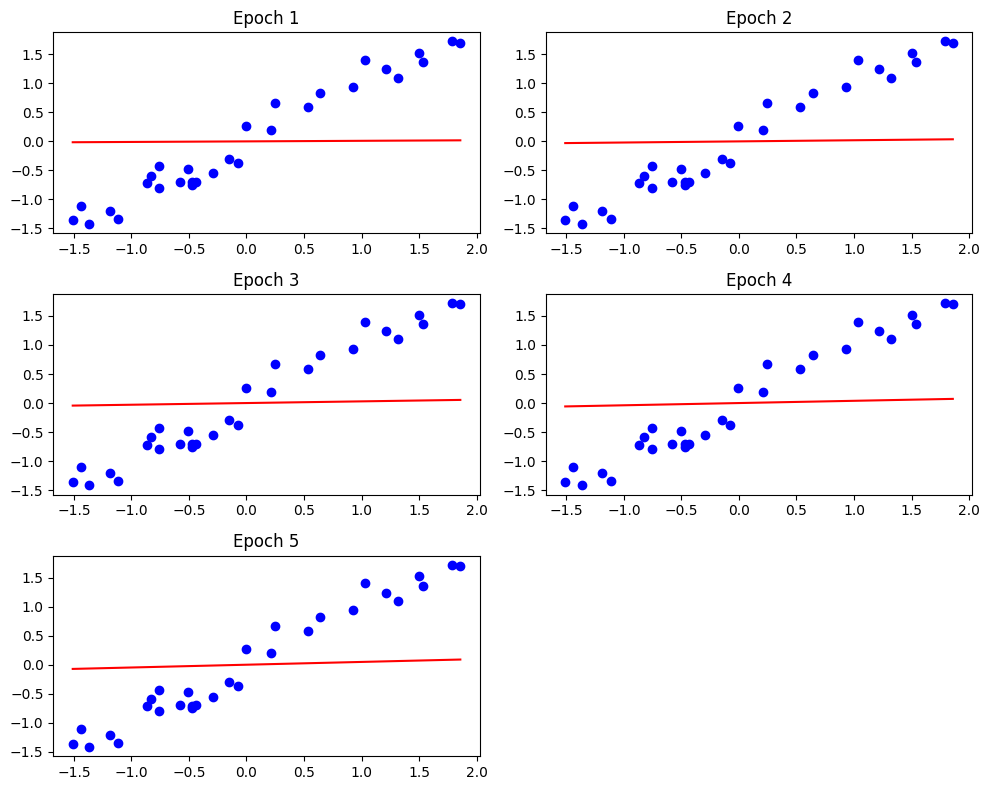

Alpha = 0.01, Final Cost = 0.454249


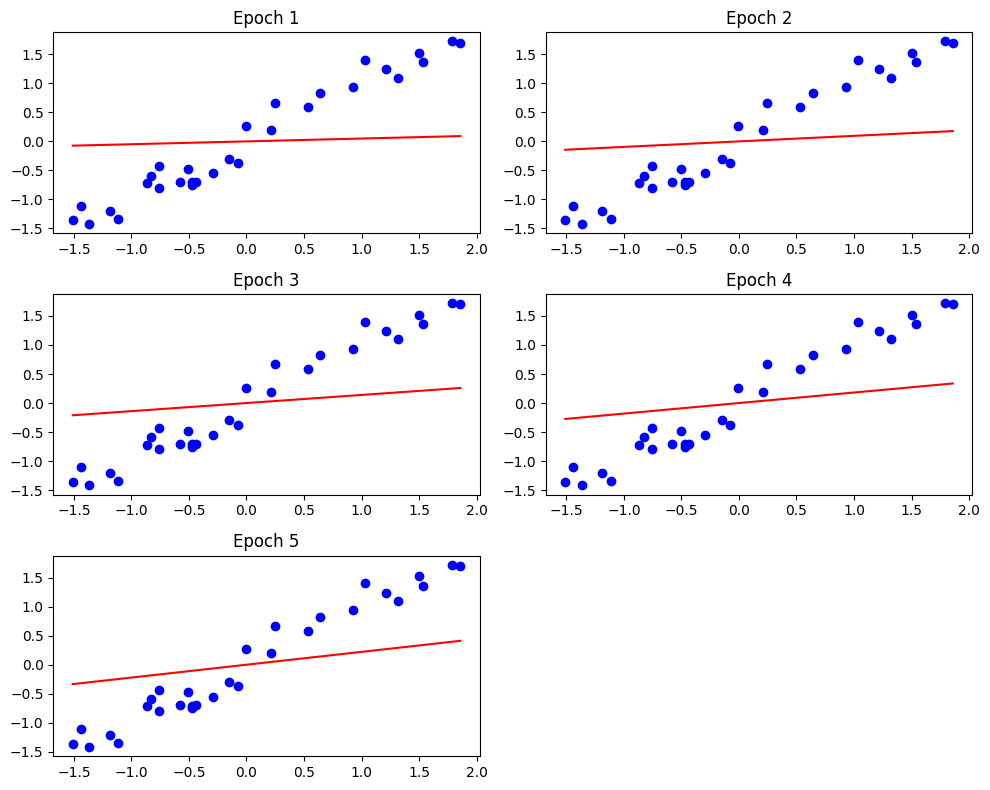

Alpha = 0.05, Final Cost = 0.308004


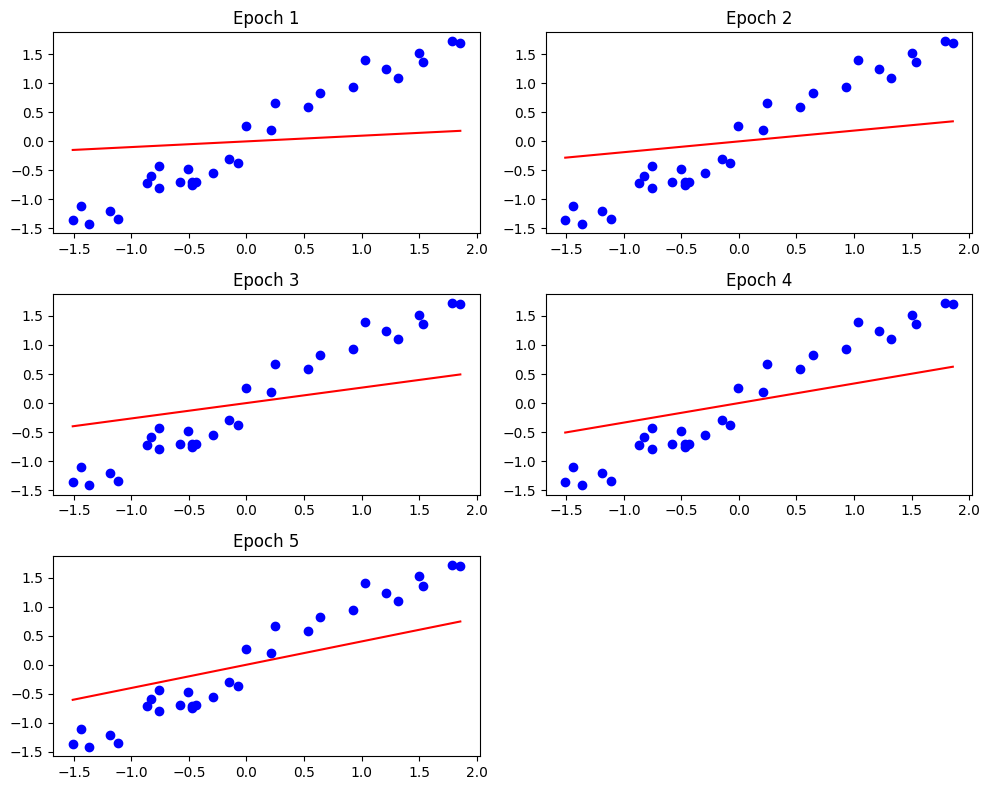

Alpha = 0.1, Final Cost = 0.188357

Best Learning Rate: 0.1 



In [138]:
alphas = [0.001, 0.01, 0.05, 0.1]
best_alpha = None
lowest_cost = float('inf')

for alpha in alphas:
    theta0, theta1, cost_history = gradient_descent(X, y, alpha, epochs=5)
    final_cost = cost_history[-1]
    print(f"Alpha = {alpha}, Final Cost = {final_cost:.6f}")
    if final_cost < lowest_cost:
        lowest_cost = final_cost
        best_alpha = alpha

print("\nBest Learning Rate:", best_alpha, "\n")

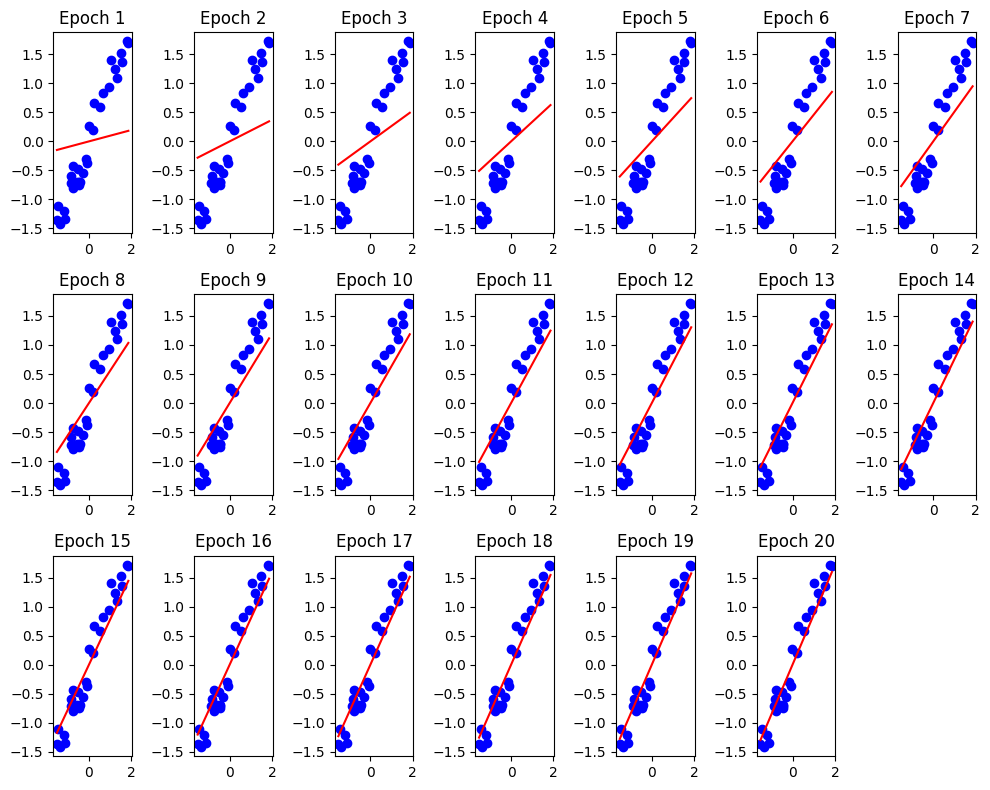

Final parameters: θ₀ = 0.0000, θ₁ = 0.8593
Final Cost: 0.028594



In [139]:
epochs = 20
theta0, theta1, cost_history = gradient_descent(X, y, best_alpha, epochs)

print(f"Final parameters: θ₀ = {theta0:.4f}, θ₁ = {theta1:.4f}")
print(f"Final Cost: {cost_history[-1]:.6f}\n")

In [140]:
y_pred = predict(X, theta0, theta1)

In [141]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

r2 = r2_score(y, y_pred)
mse = np.mean((y_pred - y) ** 2)
mae = np.mean(np.abs(y_pred - y))

print("=== Model Evaluation ===")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.6f}")
print(f"MAE: {mae:.6f}")


=== Model Evaluation ===
R² Score: 0.9428
MSE: 0.057188
MAE: 0.203648


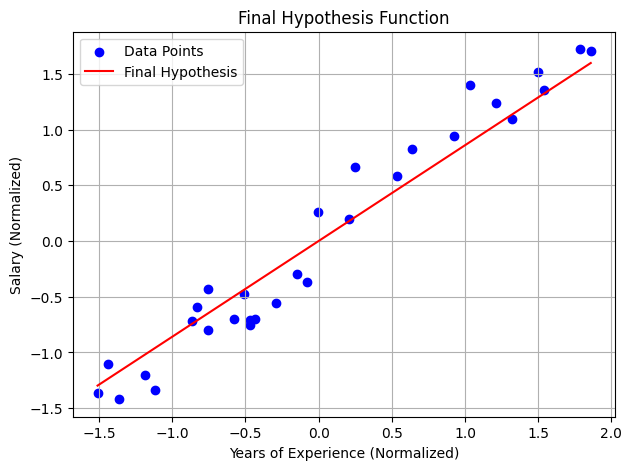

In [142]:
plt.figure(figsize=(7, 5))
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X, predict(X, theta0, theta1), color='red', label='Final Hypothesis')
plt.title("Final Hypothesis Function")
plt.xlabel("Years of Experience (Normalized)")
plt.ylabel("Salary (Normalized)")
plt.legend()
plt.grid(True)
plt.show()


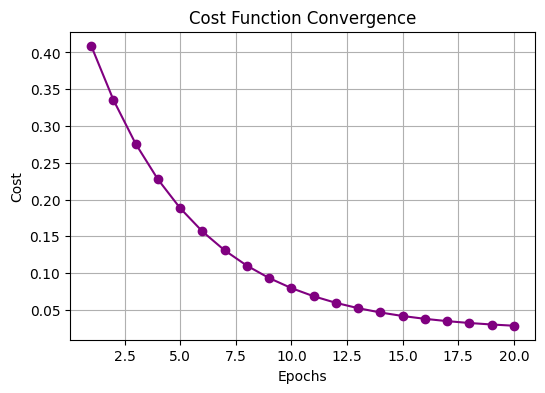

In [143]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), cost_history, color='purple', marker='o')
plt.title("Cost Function Convergence")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.grid(True)
plt.show()